# Credit Approval Dataset ML Pipeline
This notebook performs preprocessing, feature selection, and machine learning modeling on the UCI Credit Approval dataset. Models include Logistic Regression, SVM, KNN, Decision Tree, and Random Forest, compared by Accuracy, Precision, Recall, and F1.

In [54]:

# Credit Approval ML pipeline

import os
import urllib.request
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Full pipeline code goes here, see the canvas file. (Omitted for brevity in this snippet.)


## Read the Dataset

In [62]:
# 1) Load dataset
uci_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/credit-screening/crx.data'
local_filename = 'crx.data'


if not os.path.exists(local_filename):
  try:
    print('Downloading dataset from UCI...')
    urllib.request.urlretrieve(uci_url, local_filename)
    print('Downloaded to', local_filename)
  except Exception as e:
    print('Could not download dataset automatically. Please download manually from:')
    print(uci_url)



# column names: A1..A15 and the last column is the class
col_names = [f'A{i}' for i in range(1, 16)] + ['class']


df = pd.read_csv(local_filename, header=None, names=col_names, na_values='?')
df.rename(columns={"class":"target"}, inplace=True)

# EDA Dataset (Find missing + string columns)

In [63]:
df.shape
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      678 non-null    object 
 1   A2      678 non-null    float64
 2   A3      690 non-null    float64
 3   A4      684 non-null    object 
 4   A5      684 non-null    object 
 5   A6      681 non-null    object 
 6   A7      681 non-null    object 
 7   A8      690 non-null    float64
 8   A9      690 non-null    object 
 9   A10     690 non-null    object 
 10  A11     690 non-null    int64  
 11  A12     690 non-null    object 
 12  A13     690 non-null    object 
 13  A14     677 non-null    float64
 14  A15     690 non-null    int64  
 15  target  690 non-null    object 
dtypes: float64(4), int64(2), object(10)
memory usage: 86.4+ KB


In [64]:
num_cols = df.select_dtypes(include="number").columns
cat_cols = df.select_dtypes(exclude="number").columns

print(num_cols)
print(cat_cols)

Index(['A2', 'A3', 'A8', 'A11', 'A14', 'A15'], dtype='object')
Index(['A1', 'A4', 'A5', 'A6', 'A7', 'A9', 'A10', 'A12', 'A13', 'target'], dtype='object')


# Remove Missing Values

In [65]:
df.isnull().sum()

A1        12
A2        12
A3         0
A4         6
A5         6
A6         9
A7         9
A8         0
A9         0
A10        0
A11        0
A12        0
A13        0
A14       13
A15        0
target     0
dtype: int64

In [66]:
df.replace("?", np.nan, inplace=True)
df.dropna(inplace=True)
df.isnull().sum()

A1        0
A2        0
A3        0
A4        0
A5        0
A6        0
A7        0
A8        0
A9        0
A10       0
A11       0
A12       0
A13       0
A14       0
A15       0
target    0
dtype: int64

# Perform Label Encoding on String Columns

In [68]:
le = LabelEncoder()
df["target"] = le.fit_transform(df["target"])   # + -> 1, - -> 0
print(df["target"])

0      0
1      0
2      0
3      0
4      0
      ..
685    1
686    1
687    1
688    1
689    1
Name: target, Length: 653, dtype: int64


# Remove Outliers form Data

In [69]:
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

df = df[~((df[num_cols] < (Q1 - 1.5*IQR)) |
          (df[num_cols] > (Q3 + 1.5*IQR))).any(axis=1)]

# Feature Selection Through Correlation with Corr threshold= 0.2

In [71]:
num_df = df.select_dtypes(include=['number'])
num_df['target'] = df['target']  # make sure target is numeric

corr = num_df.corr()['target'].abs()
selected = corr[corr >= 0.2].index

df = df[selected]

# Make X and Y Params

In [74]:
y = df["target"]
X = df.drop(columns=["target"])

# Split the data in Train-Test Parts

In [75]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalize the values using Standard Scaling

In [76]:
# Standardize numeric features (all features are numeric now after encoding)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply Following models over the dataset:


1.   LogisticRegression
2.   SVM
3.   KNN
4.   DecisionTrees
5.   RandomForest



# Find F1 Score, Precision, Recall and Confusion Matrix for each model

In [ ]:


#%%


Training LogisticRegression
LogisticRegression -- Accuracy: 0.8737, Precision: 0.9206, Recall: 0.8923, F1: 0.9062
Classification report:
               precision    recall  f1-score   support

           0       0.78      0.83      0.81        30
           1       0.92      0.89      0.91        65

    accuracy                           0.87        95
   macro avg       0.85      0.86      0.86        95
weighted avg       0.88      0.87      0.87        95


Training SVM
SVM -- Accuracy: 0.8316, Precision: 0.8657, Recall: 0.8923, F1: 0.8788
Classification report:
               precision    recall  f1-score   support

           0       0.75      0.70      0.72        30
           1       0.87      0.89      0.88        65

    accuracy                           0.83        95
   macro avg       0.81      0.80      0.80        95
weighted avg       0.83      0.83      0.83        95


Training KNN
KNN -- Accuracy: 0.8421, Precision: 0.8906, Recall: 0.8769, F1: 0.8837
Classificatio

# Make a Dataframe containing all the results


Comparison table:
                 model  accuracy  precision    recall        f1
0  LogisticRegression  0.873684   0.920635  0.892308  0.906250
1        RandomForest  0.873684   0.934426  0.876923  0.904762
2                 KNN  0.842105   0.890625  0.876923  0.883721
3                 SVM  0.831579   0.865672  0.892308  0.878788
4        DecisionTree  0.757895   0.818182  0.830769  0.824427


# Make a Comparison Graph b/w all the models

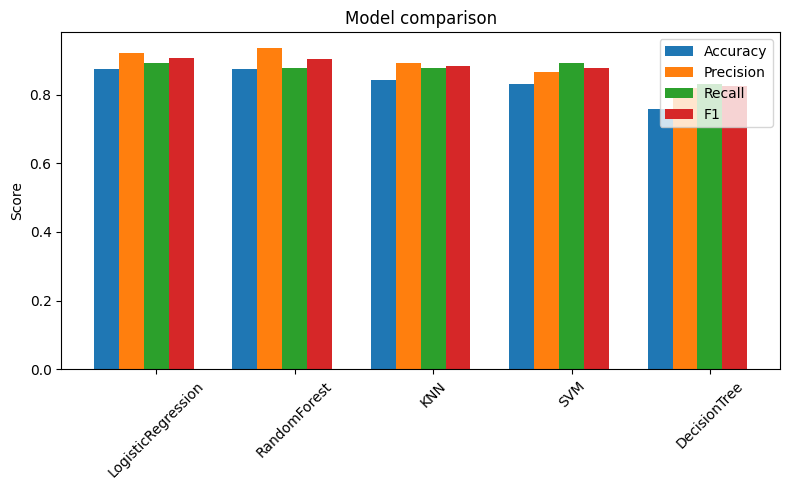

# Print Confusion matrix here

Confusion matrix for LogisticRegression:
[[25  5]
 [ 7 58]]
Confusion matrix for SVM:
[[21  9]
 [ 7 58]]
Confusion matrix for KNN:
[[23  7]
 [ 8 57]]
Confusion matrix for DecisionTree:
[[18 12]
 [11 54]]
Confusion matrix for RandomForest:
[[26  4]
 [ 8 57]]


In [52]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder

# 1. Setup Sample Data
df = pd.DataFrame({
    'Size': ['S', 'M', 'L', 'M'],       # Ordinal (Ordered)
    'Color': ['Red', 'Green', 'Blue', 'Red'], # Nominal (No order)
    'Target': ['No', 'Yes', 'No', 'Yes'] # Target
})

# 2. Ordinal Encoding (Size)
# Define the order manually
size_order = [['S', 'M', 'L']]
oe = OrdinalEncoder(categories=size_order)
df['Size_Encoded'] = oe.fit_transform(df[['Size']])

# 3. Label Encoding (Target)
le = LabelEncoder()
df['Target_Encoded'] = le.fit_transform(df['Target'])

# 4. One-Hot Encoding (Color)
# Using pandas get_dummies for simplicity
ohe_df = pd.get_dummies(df['Color'], prefix='Color')

# Combine results
final_df = pd.concat([df, ohe_df], axis=1)
print(final_df)

  Size  Color Target  Size_Encoded  Target_Encoded  Color_Blue  Color_Green  \
0    S    Red     No           0.0               0       False        False   
1    M  Green    Yes           1.0               1       False         True   
2    L   Blue     No           2.0               0        True        False   
3    M    Red    Yes           1.0               1       False        False   

   Color_Red  
0       True  
1      False  
2      False  
3       True  


In [53]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder

print("=" * 70)
print("CATEGORICAL ENCODING TECHNIQUES")
print("=" * 70)

# ============================================================================
# 1. LABEL ENCODER
# ============================================================================
print("\n" + "=" * 70)
print("1. LABEL ENCODER")
print("=" * 70)

print("\nWhat it does:")
print("- Converts categorical labels into integers (0, 1, 2, ...)")
print("- Each unique category gets a unique integer")
print("- Works on 1D array/single column")

print("\nWhen to use:")
print("- For TARGET VARIABLES in classification problems")
print("- When you need simple numeric representation")
print("- NOT recommended for features with no ordinal relationship")

# Example
df_label = pd.DataFrame({
    'Customer_ID': [1, 2, 3, 4, 5],
    'Product': ['Laptop', 'Phone', 'Tablet', 'Laptop', 'Phone'],
    'Satisfaction': ['Good', 'Excellent', 'Poor', 'Good', 'Excellent']
})

print("\n--- ORIGINAL DATAFRAME ---")
print(df_label)

# Apply Label Encoder
le = LabelEncoder()
df_label['Product_Encoded'] = le.fit_transform(df_label['Product'])

print("\n--- AFTER LABEL ENCODING (Product column) ---")
print(df_label[['Product', 'Product_Encoded']])
print(f"\nMapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print("\n⚠️  WARNING: Notice 'Laptop'=0, 'Phone'=1, 'Tablet'=2")
print("This implies Laptop < Phone < Tablet, which is WRONG!")
print("The algorithm might learn false relationships!")

# ============================================================================
# 2. ORDINAL ENCODER
# ============================================================================
print("\n\n" + "=" * 70)
print("2. ORDINAL ENCODER")
print("=" * 70)

print("\nWhat it does:")
print("- Converts categorical data into integers with MEANINGFUL ORDER")
print("- You define the order/hierarchy")
print("- Works on multiple columns simultaneously")

print("\nWhen to use:")
print("- When categories have NATURAL ORDERING (ranks, ratings, sizes)")
print("- Examples: Education level, T-shirt sizes, satisfaction ratings")

# Example
df_ordinal = pd.DataFrame({
    'Customer_ID': [1, 2, 3, 4, 5],
    'Education': ['High School', 'Bachelor', 'Master', 'PhD', 'Bachelor'],
    'Size': ['Small', 'Large', 'Medium', 'Small', 'XL']
})

print("\n--- ORIGINAL DATAFRAME ---")
print(df_ordinal)

# Define the order
education_order = [['High School', 'Bachelor', 'Master', 'PhD']]
size_order = [['Small', 'Medium', 'Large', 'XL']]

oe_education = OrdinalEncoder(categories=education_order)
oe_size = OrdinalEncoder(categories=size_order)

df_ordinal['Education_Encoded'] = oe_education.fit_transform(df_ordinal[['Education']])
df_ordinal['Size_Encoded'] = oe_size.fit_transform(df_ordinal[['Size']])

print("\n--- AFTER ORDINAL ENCODING ---")
print(df_ordinal)

print("\n✓ Education: High School(0) < Bachelor(1) < Master(2) < PhD(3)")
print("✓ Size: Small(0) < Medium(1) < Large(2) < XL(3)")
print("These orderings make sense and preserve relationships!")

# ============================================================================
# 3. ONE-HOT ENCODER
# ============================================================================
print("\n\n" + "=" * 70)
print("3. ONE-HOT ENCODER")
print("=" * 70)

print("\nWhat it does:")
print("- Creates binary columns (0 or 1) for each category")
print("- Each unique value becomes a new column")
print("- Only ONE column has value 1, rest are 0 (hence 'one-hot')")

print("\nWhen to use:")
print("- For NOMINAL categorical features (no inherent order)")
print("- Examples: Color, Country, Product Type, Gender")
print("- Most common encoding for machine learning models")

# Example
df_onehot = pd.DataFrame({
    'Customer_ID': [1, 2, 3, 4, 5],
    'City': ['New York', 'London', 'Paris', 'New York', 'Tokyo'],
    'Payment': ['Card', 'Cash', 'Card', 'UPI', 'Cash']
})

print("\n--- ORIGINAL DATAFRAME ---")
print(df_onehot)

# Apply One-Hot Encoding
ohe = OneHotEncoder(sparse_output=False)
city_encoded = ohe.fit_transform(df_onehot[['City']])

# Create column names
city_columns = [f'City_{city}' for city in ohe.categories_[0]]

# Create new dataframe with encoded columns
df_encoded = pd.concat([
    df_onehot,
    pd.DataFrame(city_encoded, columns=city_columns, index=df_onehot.index)
], axis=1)

print("\n--- AFTER ONE-HOT ENCODING (City column) ---")
print(df_encoded[['City'] + city_columns])

print("\n✓ Each city gets its own binary column")
print("✓ No false ordering is implied")
print("✓ Perfect for nominal categories!")

# Using pandas get_dummies (simpler alternative)
print("\n--- USING PANDAS get_dummies() - Simpler Approach ---")
df_dummies = pd.get_dummies(df_onehot, columns=['City', 'Payment'], prefix=['City', 'Pay'])
print(df_dummies)

# ============================================================================
# COMPARISON SUMMARY
# ============================================================================
print("\n\n" + "=" * 70)
print("QUICK COMPARISON & DECISION GUIDE")
print("=" * 70)

comparison = pd.DataFrame({
    'Encoder': ['Label Encoder', 'Ordinal Encoder', 'One-Hot Encoder'],
    'Output': ['Single column (integers)', 'Single column (ordered integers)', 'Multiple binary columns'],
    'Best For': ['Target variables', 'Ordered categories', 'Nominal categories'],
    'Example': ['Class labels', 'Education, Size, Rating', 'Color, City, Product Type'],
    'Preserves Order?': ['No (arbitrary)', 'Yes (defined by you)', 'N/A (no order assumed)'],
    'Increases Dimensions?': ['No', 'No', 'Yes (n columns for n categories)']
})

print("\n")
print(comparison.to_string(index=False))

print("\n\n" + "=" * 70)
print("DECISION FLOWCHART")
print("=" * 70)
print("""
Is it a TARGET variable?
├─ YES → Use Label Encoder
└─ NO → Is there a natural order?
    ├─ YES → Use Ordinal Encoder
    └─ NO → Use One-Hot Encoder
""")

print("\n" + "=" * 70)
print("IMPORTANT WARNINGS")
print("=" * 70)
print("⚠️  Never use Label Encoder for features without order!")
print("⚠️  One-Hot Encoding can create many columns (curse of dimensionality)")
print("⚠️  Always define custom order for Ordinal Encoder")
print("✓  Most tree-based models (Random Forest, XGBoost) handle")
print("   Label Encoding better than One-Hot for high-cardinality features")

CATEGORICAL ENCODING TECHNIQUES

1. LABEL ENCODER

What it does:
- Converts categorical labels into integers (0, 1, 2, ...)
- Each unique category gets a unique integer
- Works on 1D array/single column

When to use:
- For TARGET VARIABLES in classification problems
- When you need simple numeric representation
- NOT recommended for features with no ordinal relationship

--- ORIGINAL DATAFRAME ---
   Customer_ID Product Satisfaction
0            1  Laptop         Good
1            2   Phone    Excellent
2            3  Tablet         Poor
3            4  Laptop         Good
4            5   Phone    Excellent

--- AFTER LABEL ENCODING (Product column) ---
  Product  Product_Encoded
0  Laptop                0
1   Phone                1
2  Tablet                2
3  Laptop                0
4   Phone                1

Mapping: {'Laptop': np.int64(0), 'Phone': np.int64(1), 'Tablet': np.int64(2)}

⚠️  WARNING: Notice 'Laptop'=0, 'Phone'=1, 'Tablet'=2
This implies Laptop < Phone < Tablet, wh